# Subgenre annotations (pre-1800)

Sonnet's `subgenre` annotation task (892 pre-1800 texts) tags each with:

- **is_fiction**: bool — does this text count as fiction at all? (caught 139 non-fiction, 15.6%)
- **non_fiction_type**: type tag for the non-fiction texts
- **subgenres**: list of subgenre tags (38 distinct), e.g. `amatory_fiction`, `sentimental`, `domestic_fiction`, `gothic`, `picaresque`, etc.

Companion to `16-plot-genre.ipynb`. Two main analyses:
1. Surface the non-fiction set so we can decide later whether to filter from §15's social-network analysis.
2. Track the rise-of-the-novel transition in subgenre terms (`amatory → sentimental → domestic`).

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotnine as p9
from collections import Counter
from lltk.annotate import iter_task_results

plt.rcParams['figure.dpi'] = 110

DROPBOX_FIGS = os.path.expanduser('~/Dropbox/Prof/Books/AbsLitHist/book/figures')

df_net = pd.read_csv('../data/social_networks/social_network_analysis.csv')

rows = []
for _id, d in iter_task_results('subgenre'):
    rows.append({
        'source': _id,
        'is_fiction': d.get('is_fiction'),
        'non_fiction_type': d.get('non_fiction_type'),
        'subgenres': d.get('subgenres') or [],
    })
sg = pd.DataFrame(rows)

df = sg.merge(df_net[['source', 'year', 'author', 'title', 'form',
                      'n_chars', 'realistic_pct', 'classical_pct', 'type_pct',
                      'comp_density', 'comp_clustering', 'char_desc_conc']],
              on='source', how='left')
print(f'subgenre rows: {len(sg):,}')
print(f'  with year:      {df["year"].notna().sum():,}')
print(f'  is_fiction True/False: {df["is_fiction"].sum()} / {(df["is_fiction"]==False).sum()}')
df.head(3)

/Users/rj416/github/abslithists/abstraction/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


subgenre rows: 892
  with year:      851
  is_fiction True/False: 753 / 139


,source,is_fiction,non_fiction_type,subgenres,year,author,title,form,n_chars,realistic_pct,classical_pct,type_pct,comp_density,comp_clustering,char_desc_conc
0,_chadwyck/Early_English_Prose_Fiction/ee01010.01,True,None,"[amatory_fiction, scandalous_memoir, secret_hi...",1699.0,Anon.,The Adventures of Covent&hyphen;Garden (1699),romance,6.0,0.0,33.3,16.7,0.2667,0.2778,-0.467551
1,_chadwyck/Early_English_Prose_Fiction/ee01010.02,True,None,"[frame_tale, amatory_fiction, domestic_fiction...",1696.0,Anon.,Alcander and Philocrates (1696),romance,32.0,3.1,15.6,46.9,0.0474,0.2109,-0.524978
2,_chadwyck/Early_English_Prose_Fiction/ee01010.03,True,None,"[pseudo_memoir, scandalous_memoir, historical_...",1663.0,Anon.,The Case of Madam Mary Carlton (1663),?,26.0,73.1,0.0,11.5,0.0369,0.0201,-0.195659


## 1. The non-fiction filter

What did Sonnet flag as non-fiction? Distribution by type, year, and corpus.

In [2]:
nonfic = df[df['is_fiction'] == False].copy()
print(f'{len(nonfic):,} non-fiction texts ({len(nonfic)/len(df)*100:.1f}% of subgenre-tagged)')
print()
print('=== non_fiction_type distribution ===')
print(nonfic['non_fiction_type'].value_counts(dropna=False).to_string())
print()

nonfic['decade'] = (nonfic['year'] // 10 * 10).astype('Int64')
print('=== non-fiction by decade (counts) ===')
print(nonfic.groupby('decade').size().to_string())
print()

# Sample some non-fiction titles
print('=== 25 non-fiction examples (titles) ===')
samp = nonfic[['year', 'author', 'title', 'non_fiction_type']].sort_values('year').head(25)
print(samp.to_string(index=False))

139 non-fiction texts (15.6% of subgenre-tagged)

=== non_fiction_type distribution ===
non_fiction_type
treatise      29
poetry        28
essay         22
history       18
biography      9
reference      9
letters        7
legal          6
sermon         5
drama          2
None           2
almanac        1
periodical     1

=== non-fiction by decade (counts) ===
decade
1480     1
1490     1
1500     1
1530     3
1560     2
1570     5
1580     7
1590     9
1600    19
1610     6
1620     6
1630     7
1640     4
1650     1
1660     1
1670     3
1680     6
1690     4
1700     3
1710     1
1720     2
1740     1
1750     2
1760     2
1780     1
1790     4

=== 25 non-fiction examples (titles) ===
  year                author                                              title non_fiction_type
1484.0        La Tour Landry [Here begynneth the booke which the knyght of the          treatise
1496.0               Joannes           [The lyfe of the thre kynges of Coleyne]          history
1503.0  

### Plot: non-fiction share over time

Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/subgenre_nonfiction_share_25y.png


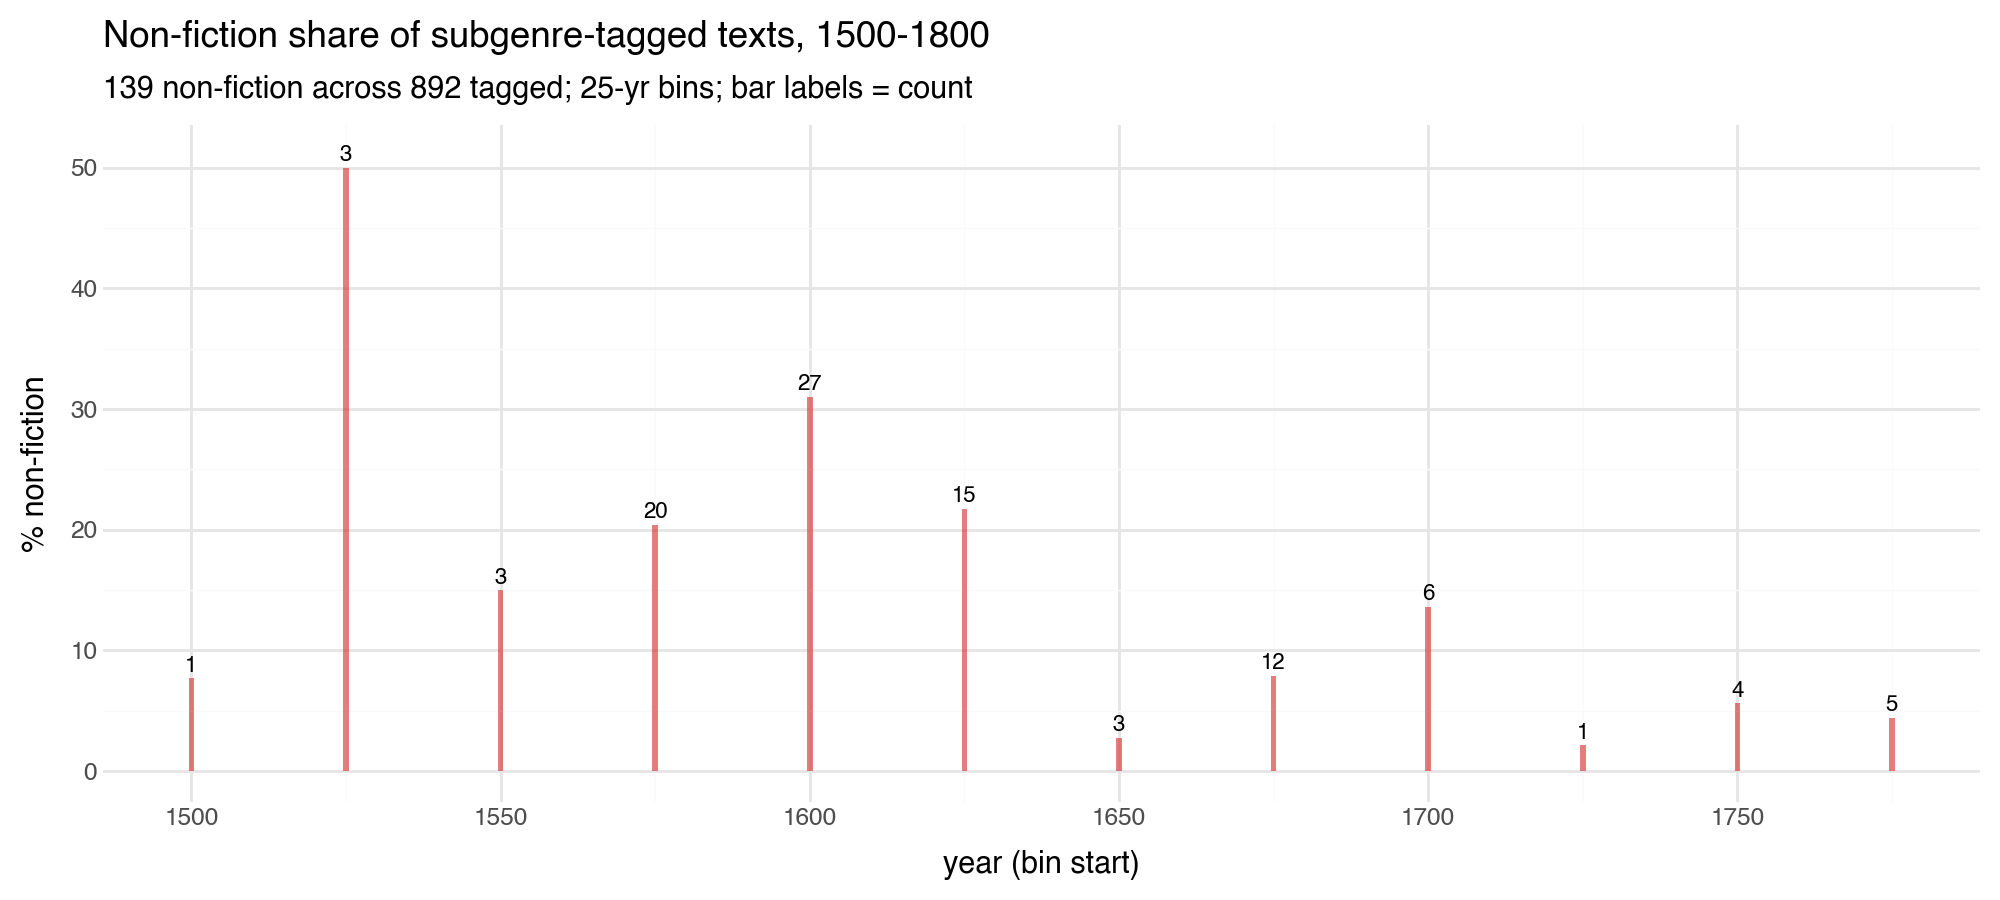

In [3]:
dia = df[(df['year'] >= 1500) & (df['year'] < 1800)].copy()
dia['bin'] = (dia['year'] // 25 * 25).astype(int)
nf_by_bin = (dia.groupby('bin')
             .agg(total=('source', 'count'),
                  nonfic=('is_fiction', lambda s: (s == False).sum()))
             .reset_index())
nf_by_bin['pct'] = nf_by_bin['nonfic'] / nf_by_bin['total'] * 100

p_nf = (p9.ggplot(nf_by_bin, p9.aes(x='bin', y='pct'))
        + p9.geom_col(fill='#d62728', alpha=0.6)
        + p9.geom_text(p9.aes(label='nonfic'), nudge_y=1, size=8)
        + p9.scale_x_continuous(breaks=range(1500, 1801, 50))
        + p9.labs(
            title='Non-fiction share of subgenre-tagged texts, 1500-1800',
            subtitle=f'{(df["is_fiction"]==False).sum()} non-fiction across {len(df):,} tagged; 25-yr bins; bar labels = count',
            x='year (bin start)', y='% non-fiction',
        )
        + p9.theme_minimal()
        + p9.theme(figure_size=(10, 4.5)))

out = os.path.join(DROPBOX_FIGS, 'subgenre_nonfiction_share_25y.png')
p_nf.save(out, dpi=300, verbose=False)
print(f'Saved to {out}')
p_nf

**Decision deferred** — these 139 texts are visible above but NOT filtered from any other notebook. Decide later whether to propagate `is_fiction == True` as a global filter or treat case-by-case.

## 2. Subgenre vocabulary

Each text can have multiple subgenre tags. Total tags and frequency.

In [4]:
# Explode the list-valued subgenres
fic = df[df['is_fiction'] == True].copy()
sg_counter = Counter()
for tags in fic['subgenres']:
    for t in tags:
        sg_counter[t] += 1
print(f'{len(sg_counter)} distinct subgenre tags across {len(fic):,} fiction texts')
print()
print('Counts:')
for tag, n in sg_counter.most_common():
    print(f'  {n:5}  {tag}')

38 distinct subgenre tags across 753 fiction texts

Counts:
    292  sentimental
    219  frame_tale
    215  historical_fiction
    211  domestic_fiction
    177  amatory_fiction
    169  heroic_romance
    133  pseudo_memoir
    104  picaresque
    100  menippean_satire
     99  allegory
     98  philosophical_tale
     85  travel_narrative
     79  conduct_fiction
     78  epistolary
     63  rogue_fiction
     54  scandalous_memoir
     47  pastoral
     37  secret_history
     32  gothic
     27  newgate_narrative
     27  imaginary_voyage
     25  roman_a_clef
     25  anti_romance
     22  fabliau
     21  captivity_narrative
     20  oriental_tale
     20  parody
     19  exemplum
     18  fairy_tale
     18  beast_fable
     17  anatomy
     15  providence_tale
     14  spiritual_autobiography
     11  robinsonade
     11  children_fiction
      9  jacobin_novel
      8  national_tale
      4  it_narrative


## 3. Subgenre composition over time (top-12)

For the 12 most-common subgenres, plot per-bin share of fiction texts that carry the tag (multi-label, so shares can sum to >100%).

Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/subgenre_top12_25y.png


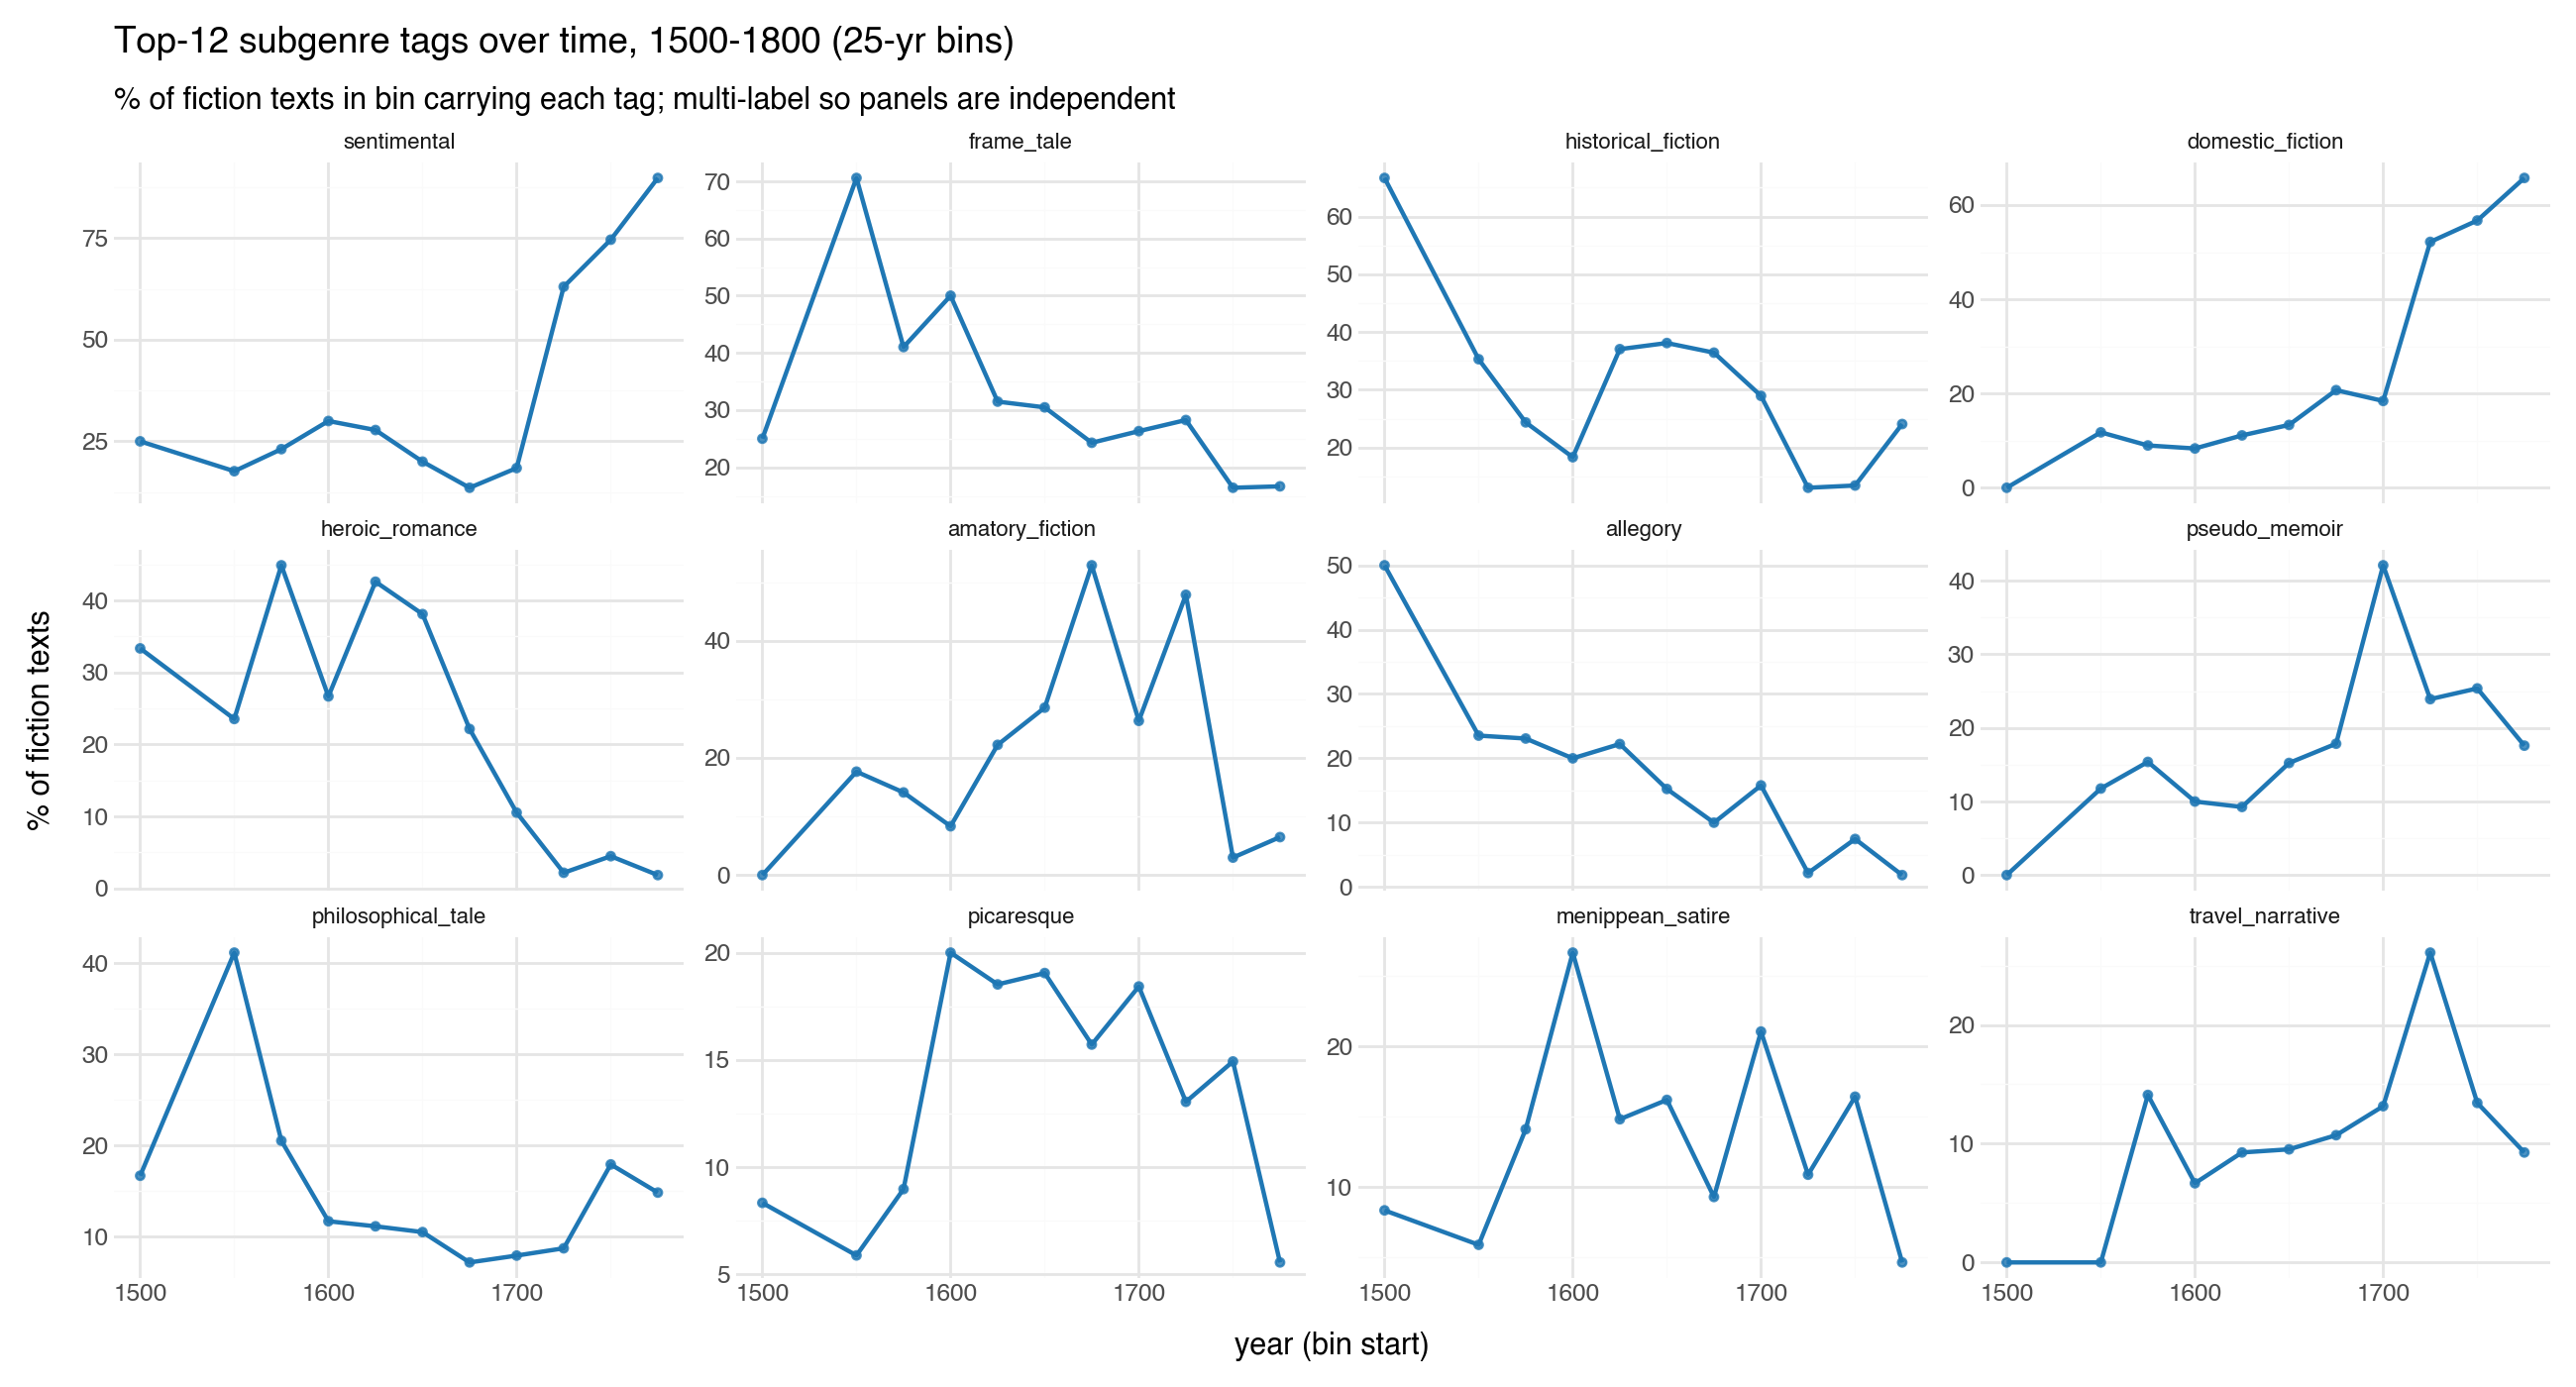

In [5]:
TOP_K = 12
MIN_N = 8
top_tags = [t for t, _ in sg_counter.most_common(TOP_K)]

dia = fic[(fic['year'] >= 1500) & (fic['year'] < 1800)].copy()
dia['bin'] = (dia['year'] // 25 * 25).astype(int)

long_rows = []
for tag in top_tags:
    has_tag = dia['subgenres'].apply(lambda L: tag in L)
    grp = dia.assign(has_tag=has_tag).groupby('bin').agg(
        n=('has_tag', 'sum'),
        total=('has_tag', 'count'),
    ).reset_index()
    grp = grp[grp['total'] >= MIN_N].copy()
    grp['pct'] = grp['n'] / grp['total'] * 100
    grp['subgenre'] = tag
    long_rows.append(grp)
sg_long = pd.concat(long_rows, ignore_index=True)

# Order facets by overall mean pct
order = (sg_long.groupby('subgenre')['pct'].mean()
         .sort_values(ascending=False).index.tolist())
sg_long['subgenre'] = pd.Categorical(sg_long['subgenre'], categories=order, ordered=True)

p_sg = (p9.ggplot(sg_long, p9.aes(x='bin', y='pct'))
        + p9.geom_line(color='#1f77b4', size=0.9)
        + p9.geom_point(color='#1f77b4', size=1.2, alpha=0.8)
        + p9.facet_wrap('~ subgenre', ncol=4, scales='free_y')
        + p9.scale_x_continuous(breaks=range(1500, 1801, 100))
        + p9.labs(
            title=f'Top-{TOP_K} subgenre tags over time, 1500-1800 (25-yr bins)',
            subtitle=f'% of fiction texts in bin carrying each tag; multi-label so panels are independent',
            x='year (bin start)', y='% of fiction texts',
        )
        + p9.theme_minimal()
        + p9.theme(figure_size=(13, 7),
                   strip_text=p9.element_text(size=8)))

out = os.path.join(DROPBOX_FIGS, 'subgenre_top12_25y.png')
p_sg.save(out, dpi=300, verbose=False)
print(f'Saved to {out}')
p_sg

## 4. The amatory → sentimental → domestic transition

lltm-claude's headline finding: amatory_fiction surges 1650-99, sentimental dominates 1750-99 (80% of texts), domestic_fiction rises 0 → 109 in the same period. Plot all three on one axis.

Saved to /Users/rj416/Dropbox/Prof/Books/AbsLitHist/book/figures/subgenre_amatory_sentimental_domestic_25y.png


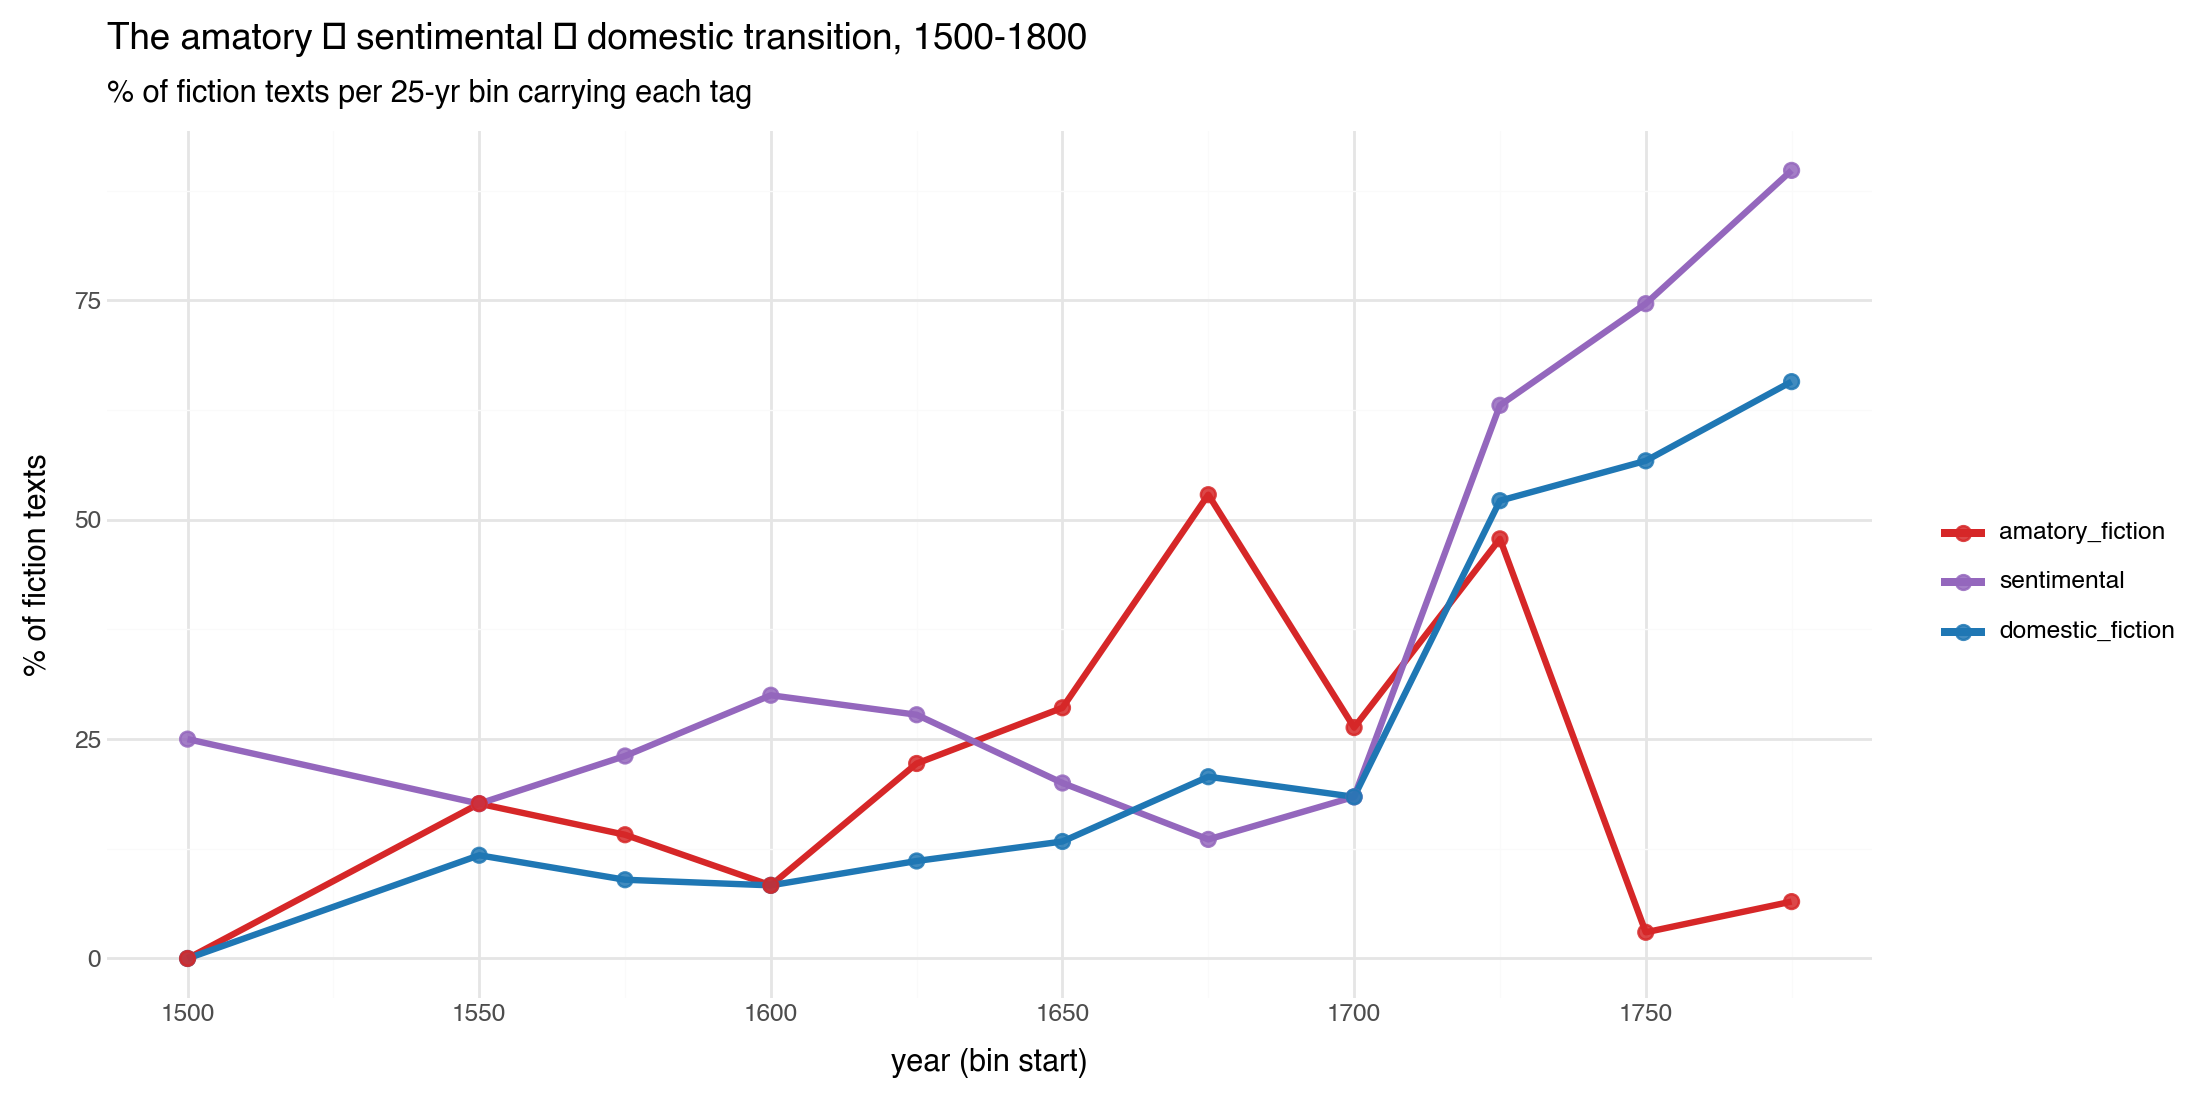

In [6]:
focus = ['amatory_fiction', 'sentimental', 'domestic_fiction']
focus_long = sg_long[sg_long['subgenre'].isin(focus)].copy()
focus_long['subgenre'] = pd.Categorical(focus_long['subgenre'], categories=focus, ordered=True)

p_trans = (p9.ggplot(focus_long, p9.aes(x='bin', y='pct', color='subgenre'))
           + p9.geom_line(size=1.3)
           + p9.geom_point(size=2.5, alpha=0.85)
           + p9.scale_color_manual(values={
               'amatory_fiction':  '#d62728',  # red (older)
               'sentimental':      '#9467bd',  # purple (transition)
               'domestic_fiction': '#1f77b4',  # blue (newer)
           })
           + p9.scale_x_continuous(breaks=range(1500, 1801, 50))
           + p9.labs(
               title='The amatory → sentimental → domestic transition, 1500-1800',
               subtitle=f'% of fiction texts per 25-yr bin carrying each tag',
               x='year (bin start)', y='% of fiction texts',
               color='',
           )
           + p9.theme_minimal()
           + p9.theme(figure_size=(11, 5.5)))

out = os.path.join(DROPBOX_FIGS, 'subgenre_amatory_sentimental_domestic_25y.png')
p_trans.save(out, dpi=300, verbose=False)
print(f'Saved to {out}')
p_trans